### Note:
    I tried to make this to match yasin's dicom header viewer, overall it is doing OK, but still some details are not matched, like GridFrameOffsetVector is NUMBER not STRING

In [1]:
import os
import sys
sys.path.append('/homebase/DL_projects/brainmets/1210_wip/code')

from mydicomreader.myRTDoseReader import myRTDoseReader


In [2]:
# Define the path to the RTDOSE DICOM file
path_mr = "/database/brainmets/dicom/SBRT_research_mim_export_20251209_organized/SRS0944/1998-11__Studies/SRS0944_SRS0944_MR_1998-11-12_000000_._axial_n45__00000/2.16.840.1.114362.1.12046989.25631758973.631599597.739.2292.dcm"
path_rtdose = "/database/brainmets/dicom/SBRT_research_mim_export_20251209_organized/SRS0944/1998-11__Studies/SRS0944_SRS0944_RTDOSE_1998-11-12_000000_._._n1__00000/2.16.840.1.114362.1.12046989.25631758973.631599598.618.2343.dcm"

# Create an instance of the RTDose reader
rtdose_reader = myRTDoseReader(path_rtdose)

In [3]:
# Print metadata using pydicom
rtdose_reader.print_metadata_pydicom()


DICOM Metadata (using pydicom) - File: 2.16.840.1.114362.1.12046989.25631758973.631599598.618.2343.dcm
Keyword                             Tag             VR    VM    Type            Value
------------------------------------------------------------------------------------------------------------------------
SpecificCharacterSet                (0008,0005)     CS    1     String               ISO_IR 192
ImageType                           (0008,0008)     CS    3     String               ['DERIVED', 'SECONDARY', 'DOSE']
InstanceCreationDate                (0008,0012)     DA    1     Date                 20230115
InstanceCreationTime                (0008,0013)     TM    1     Time                 130209
SOPClassUID                         (0008,0016)     UI    1     UID                  1.2.840.10008.5.1.4.1.1.481.2
SOPInstanceUID                      (0008,0018)     UI    1     UID                  2.16.840.1.114362.1.12046989.25631758973.631599598.618.2343
StudyDate                     

In [4]:
# Print metadata using SimpleITK
rtdose_reader.print_metadata_sitk()


DICOM Metadata (using SimpleITK) - File: 2.16.840.1.114362.1.12046989.25631758973.631599598.618.2343.dcm
Keyword                             Tag             VR    VM    Type                 Value
------------------------------------------------------------------------------------------------------------------------
SpecificCharacterSet                (0008,0005)     CS    1     String               ISO_IR 192
ImageType                           (0008,0008)     CS    3     String               DERIVED\SECONDARY\DOSE
InstanceCreationDate                (0008,0012)     DA    1     Date                 20230115
InstanceCreationTime                (0008,0013)     TM    1     Time                 130209
SOPClassUID                         (0008,0016)     UI    1     UID                  1.2.840.10008.5.1.4.1.1.481.2
SOPInstanceUID                      (0008,0018)     UI    1     UID                  2.16.840.1.114362.1.12046989.25631758973.631599598.618.2343
StudyDate                        

### Mismatch between ReadImageInformation and ReadImage

    When SimpleITK actually loads the image, it may apply a consistency fix so the image has a conventional representation:
    
    spacing components are positive
    
    the “flip” is represented via Direction (and sometimes Origin adjustment / frame reordering)

In [18]:
import SimpleITK as sitk

rtdose_reader = sitk.ImageFileReader()
rtdose_reader.SetFileName(path_rtdose)
rtdose_reader.LoadPrivateTagsOn()
rtdose_reader.ReadImageInformation()

print("Header-only:")
print("  spacing :", rtdose_reader.GetSpacing())
print("  origin  :", rtdose_reader.GetOrigin())
print("  dir     :", rtdose_reader.GetDirection())
print("  size    :", rtdose_reader.GetSize())

rtdose_img = sitk.ReadImage(path_rtdose)
print("\nLoaded image:")
print("  spacing :", rtdose_img.GetSpacing())
print("  origin  :", rtdose_img.GetOrigin())
print("  dir     :", rtdose_img.GetDirection())
print("  size    :", rtdose_img.GetSize())


Header-only:
  spacing : (0.5, 0.5, -0.5)
  origin  : (79.3591909, 51.977389, 11.8168963)
  dir     : (1.0, 4.00008225e-17, -3.960114249999999e-18, -4.00008225e-17, 1.0, 1.40946282e-17, 3.96011425e-18, -1.40946282e-17, 1.0)
  size    : (302, 393, 321)

Loaded image:
  spacing : (0.5, 0.5, 0.5)
  origin  : (79.3591909, 51.977389, 11.8168963)
  dir     : (1.0, 4.00008225e-17, 3.960114249999999e-18, -4.00008225e-17, 1.0, -1.40946282e-17, 3.96011425e-18, -1.40946282e-17, -1.0)
  size    : (302, 393, 321)


In [19]:
p0 = rtdose_img.TransformIndexToPhysicalPoint((0,0,0))
p1 = rtdose_img.TransformIndexToPhysicalPoint((0,0,1))
print("Physical step (z=0 -> z=1):", [p1[i]-p0[i] for i in range(3)])


Physical step (z=0 -> z=1): [0.0, 0.0, -0.5]


In [23]:
import os
import SimpleITK as sitk


def read_dicom_series(folder: str, series_uid: str | None = None) -> tuple[sitk.Image, list[str], str]:
    """
    Read a DICOM series (3D volume) from a folder.

    If series_uid is None, it picks the series with the most slices.
    Returns (image, file_list, chosen_series_uid).
    """
    if not os.path.isdir(folder):
        raise FileNotFoundError(f"Not a folder: {folder}")

    series_ids = sitk.ImageSeriesReader.GetGDCMSeriesIDs(folder)
    if not series_ids:
        raise RuntimeError(f"No DICOM series found in: {folder}")

    if series_uid is None:
        # pick the series with the most files (usually the actual volume)
        best_id = None
        best_n = -1
        for sid in series_ids:
            files = sitk.ImageSeriesReader.GetGDCMSeriesFileNames(folder, sid)
            if len(files) > best_n:
                best_n = len(files)
                best_id = sid
        series_uid = best_id

    file_list = sitk.ImageSeriesReader.GetGDCMSeriesFileNames(folder, series_uid)
    if not file_list:
        raise RuntimeError(f"Series UID {series_uid} has no files in: {folder}")

    reader = sitk.ImageSeriesReader()
    reader.SetFileNames(file_list)

    # optional but often helpful for DICOM:
    reader.MetaDataDictionaryArrayUpdateOn()
    reader.LoadPrivateTagsOn()

    img3d = reader.Execute()
    return img3d, file_list, series_uid


In [28]:
folder_mr = "/database/brainmets/dicom/SBRT_research_mim_export_20251209_organized/SRS0944/1998-11__Studies/SRS0944_SRS0944_MR_1998-11-12_000000_._axial_n45__00000"
mr_img, mr_files, mr_uid = read_dicom_series(folder_mr)
print("MR series UID:", mr_uid)
print("MR size:", mr_img.GetSize())
print("MR spacing:", mr_img.GetSpacing())
print("MR origin:", mr_img.GetOrigin())
print("MR direction:", mr_img.GetDirection())

MR series UID: 2.16.840.1.114362.1.12046989.25631758973.631599597.739.2294
MR size: (256, 256, 45)
MR spacing: (1.0, 1.0, 1.0)
MR origin: (0.0, 0.0, 0.0)
MR direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)


In [26]:
import SimpleITK as sitk


def resample_to_reference(
    moving: sitk.Image,
    reference: sitk.Image,
    *,
    transform: sitk.Transform | None = None,
    interpolator: int | None = None,
    default_value: float = 0.0,
    output_pixel_type: int | None = None,
) -> sitk.Image:
    """
    Resample `moving` onto the grid of `reference`.

    Parameters
    ----------
    moving : sitk.Image
        Image to be resampled (e.g., RTDOSE).
    reference : sitk.Image
        Target grid (e.g., CT/MR DICOM image) providing spacing/origin/direction/size.
    transform : sitk.Transform | None
        Physical transform mapping reference -> moving. For same patient space, use identity.
        If you already registered images, pass that transform here.
    interpolator : int | None
        sitk interpolator. If None, auto-choose:
          - sitkLinear for scalar images (dose, CT, MR)
          - sitkNearestNeighbor for labels (mask)
    default_value : float
        Value for samples outside moving image support (dose outside grid -> 0).
    output_pixel_type : int | None
        Output pixel type. If None, keep moving's pixel type.

    Returns
    -------
    sitk.Image
        moving resampled onto reference grid.
    """
    if transform is None:
        transform = sitk.Transform(3, sitk.sitkIdentity)

    if interpolator is None:
        # Heuristic: use NN for integer-ish label images, linear otherwise.
        # RTDOSE is scalar -> linear.
        is_label_like = moving.GetPixelID() in (
            sitk.sitkUInt8, sitk.sitkInt8,
            sitk.sitkUInt16, sitk.sitkInt16,
            sitk.sitkUInt32, sitk.sitkInt32,
            sitk.sitkUInt64, sitk.sitkInt64,
        )
        interpolator = sitk.sitkNearestNeighbor if is_label_like else sitk.sitkLinear

    if output_pixel_type is None:
        output_pixel_type = moving.GetPixelID()

    return sitk.Resample(
        moving,
        reference,              # defines output grid
        transform,              # maps output (reference) physical points into moving
        interpolator,
        default_value,
        output_pixel_type,
    )


In [29]:
dose_on_mr = resample_to_reference(
    moving=rtdose_img,
    reference=mr_img,
    interpolator=sitk.sitkLinear,
    default_value=0.0,
    output_pixel_type=sitk.sitkFloat32,
)

In [30]:
print("MR size:", mr_img.GetSize())
print("MR spacing:", mr_img.GetSpacing())
print("MR origin:", mr_img.GetOrigin())
print("MR direction:", mr_img.GetDirection())

print("dose_on_mr size:", dose_on_mr.GetSize())
print("dose_on_mr spacing:", dose_on_mr.GetSpacing())
print("dose_on_mr origin:", dose_on_mr.GetOrigin())
print("dose_on_mr direction:", dose_on_mr.GetDirection())

MR size: (256, 256, 45)
MR spacing: (1.0, 1.0, 1.0)
MR origin: (0.0, 0.0, 0.0)
MR direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
dose_on_mr size: (256, 256, 45)
dose_on_mr spacing: (1.0, 1.0, 1.0)
dose_on_mr origin: (0.0, 0.0, 0.0)
dose_on_mr direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)


(45, 256, 256)
(45, 256, 256)


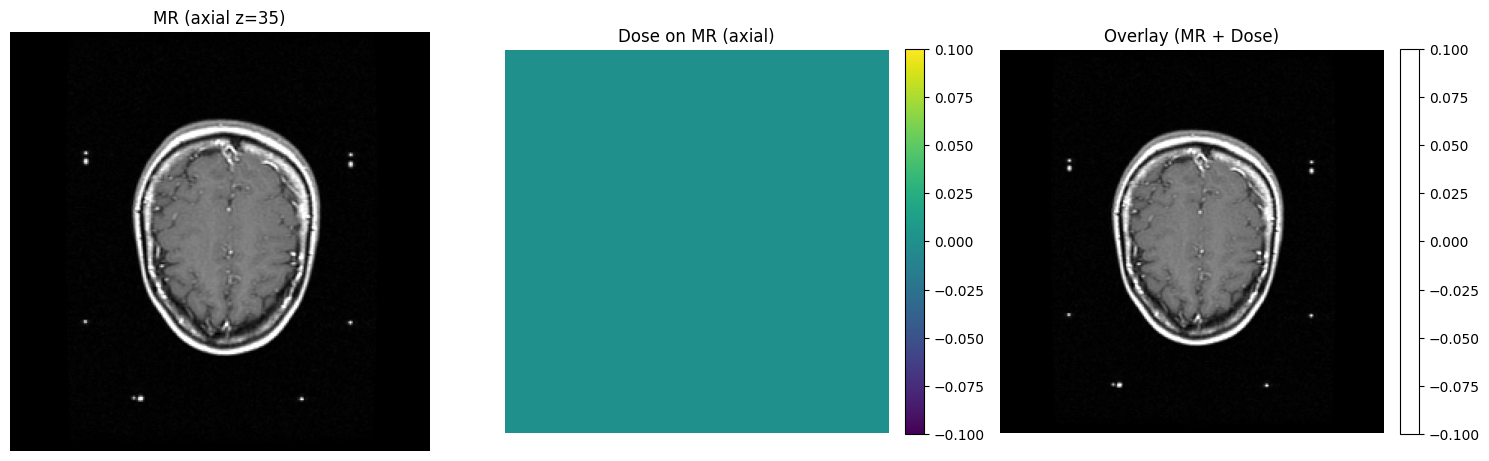

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk

# Convert SimpleITK images -> numpy (z, y, x)
mr_np   = sitk.GetArrayFromImage(mr_img).astype(np.float32)
dose_np = sitk.GetArrayFromImage(dose_on_mr).astype(np.float32)
print(mr_np.shape)
print(dose_np.shape)
# Central axial slice index
z0 = mr_np.shape[0] // 2
z0 = 10
z0 = 35

mr_sl   = mr_np[z0, :, :]
dose_sl = dose_np[z0, :, :]

# Robust windowing for MR display
p1, p99 = np.percentile(mr_sl[np.isfinite(mr_sl)], [1, 99])
mr_disp = np.clip(mr_sl, p1, p99)

# Robust scaling for dose display
# (Often dose is 0 outside the grid; keep 0 as baseline)
dose_valid = dose_sl[np.isfinite(dose_sl)]
dmax = np.percentile(dose_valid, 99) if np.any(dose_valid) else 0.0
dmax = float(dmax) if dmax > 0 else float(np.max(dose_sl))  # fallback

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1) MR
axes[0].imshow(mr_disp, cmap="gray", origin="lower")
axes[0].set_title(f"MR (axial z={z0})")
axes[0].axis("off")

# 2) Dose
im1 = axes[1].imshow(dose_sl, origin="lower", vmin=0, vmax=dmax)
axes[1].set_title("Dose on MR (axial)")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# 3) Overlay (MR + dose heatmap with alpha)
axes[2].imshow(mr_disp, cmap="gray", origin="lower")

if dmax > 0:
    alpha = np.clip(dose_sl / dmax, 0, 1) * 0.8  # 0..0.8 transparency
else:
    alpha = 0.0

im2 = axes[2].imshow(dose_sl, origin="lower", vmin=0, vmax=dmax, alpha=alpha)
axes[2].set_title("Overlay (MR + Dose)")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


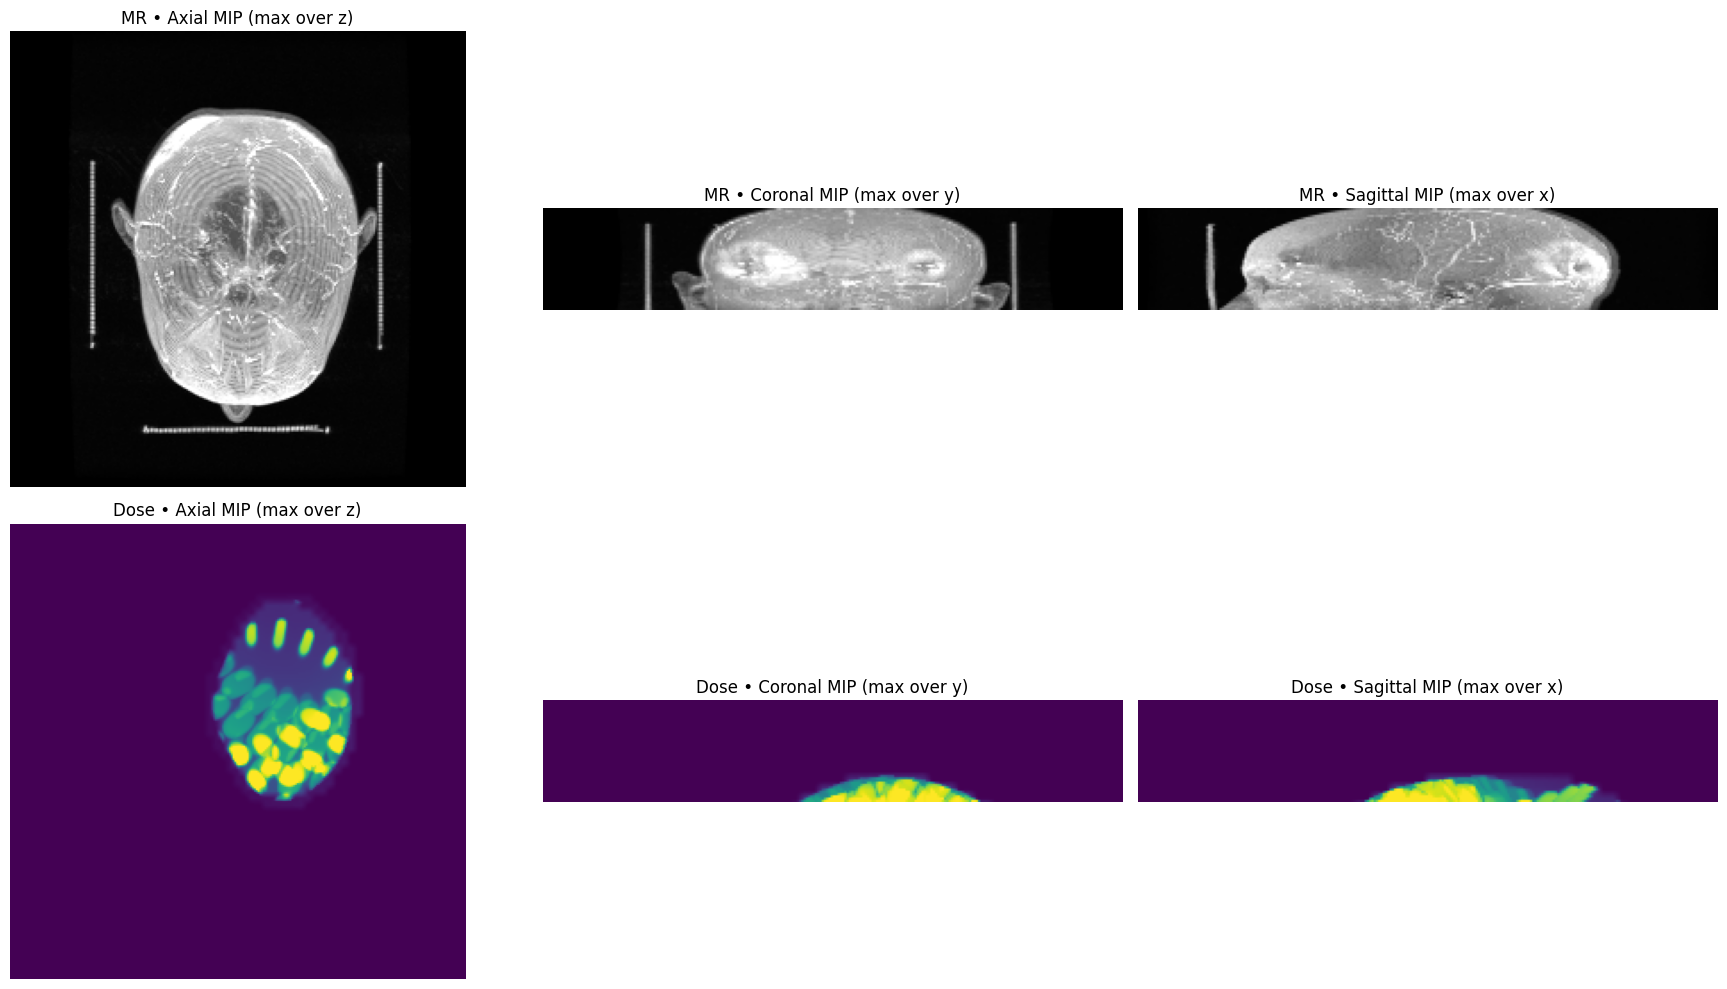

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# mr_np, dose_np are assumed to already exist as numpy arrays with shape (z, y, x)

def mip_3views(vol_zyx: np.ndarray):
    """Return 3-view MIPs from a (z,y,x) volume."""
    v = np.asarray(vol_zyx)
    axial    = np.nanmax(v, axis=0)  # (y, x)  max over z
    coronal  = np.nanmax(v, axis=1)  # (z, x)  max over y
    sagittal = np.nanmax(v, axis=2)  # (z, y)  max over x
    return axial, coronal, sagittal

def robust_clip(img2d: np.ndarray, p_lo=1, p_hi=99):
    x = img2d[np.isfinite(img2d)]
    if x.size == 0:
        return img2d
    lo, hi = np.percentile(x, [p_lo, p_hi])
    if hi <= lo:
        return img2d
    return np.clip(img2d, lo, hi)

mr_mips   = mip_3views(mr_np)
dose_mips = mip_3views(dose_np)

titles = ["Axial MIP (max over z/SI)", "Coronal MIP (max over y/AP)", "Sagittal MIP (max over x/LR)"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: MR (grayscale)
for j in range(3):
    img = robust_clip(mr_mips[j], 1, 99)
    axes[0, j].imshow(img, cmap="gray", origin="lower")
    axes[0, j].set_title(f"MR • {titles[j]}")
    axes[0, j].axis("off")

# Row 2: Dose (heatmap default)
for j in range(3):
    img = dose_mips[j]
    # Keep 0 as baseline if dose is mostly nonnegative; robust vmax for visibility
    x = img[np.isfinite(img)]
    vmax = np.percentile(x, 99) if x.size else None
    if vmax is not None and vmax > 0:
        axes[1, j].imshow(img, origin="lower", vmin=0, vmax=vmax)
    else:
        axes[1, j].imshow(img, origin="lower")
    axes[1, j].set_title(f"Dose • {titles[j]}")
    axes[1, j].axis("off")

plt.tight_layout()
plt.show()


In [36]:
import numpy as np
import matplotlib.pyplot as plt

titles = ["Axial MIP (max over z/SI)", "Coronal MIP (max over y/AP)", "Sagittal MIP (max over x/LR)"]

def plot_3view_mip(
    vol_zyx: np.ndarray,
    *,
    titles_3=titles,
    cmap=None,
    origin="lower",
    p_lo=1,
    p_hi=99,
    vmin=None,
    vmax=None,
    assume_nonnegative=False,
    add_colorbar=False,
    figsize=(15, 5),
    suptitle=None,
):
    """
    Plot 3-view MIPs (Axial/Coronal/Sagittal) from a 3D numpy array in (z,y,x) order.

    Parameters
    ----------
    vol_zyx : np.ndarray
        3D volume with shape (z, y, x).
    titles_3 : list[str]
        3 titles for the 3 panels.
    cmap : str | None
        Matplotlib colormap. Use 'gray' for MR/CT.
    p_lo, p_hi : float
        Percentile clipping for display if vmin/vmax are not provided.
    vmin, vmax : float | None
        Display range. If None, uses robust percentiles.
    assume_nonnegative : bool
        If True and vmin is None, uses vmin=0 (useful for dose).
    add_colorbar : bool
        If True, adds a colorbar to each panel.
    """
    vol = np.asarray(vol_zyx)
    if vol.ndim != 3:
        raise ValueError(f"Expected a 3D array (z,y,x). Got shape={vol.shape}")

    # 3-view MIPs from (z,y,x)
    mips = [
        np.nanmax(vol, axis=0),  # axial: (y,x)
        np.nanmax(vol, axis=1),  # coronal: (z,x)
        np.nanmax(vol, axis=2),  # sagittal: (z,y)
    ]

    def _robust_range(img):
        x = img[np.isfinite(img)]
        if x.size == 0:
            return (0.0, 1.0)
        lo, hi = np.percentile(x, [p_lo, p_hi])
        if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
            lo, hi = float(np.nanmin(img)), float(np.nanmax(img))
        if assume_nonnegative:
            lo = 0.0 if (vmin is None) else lo
        return lo, hi

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    if suptitle:
        fig.suptitle(suptitle)

    for ax, img, t in zip(axes, mips, titles_3):
        if vmin is None or vmax is None:
            lo, hi = _robust_range(img)
            _vmin = lo if vmin is None else vmin
            _vmax = hi if vmax is None else vmax
        else:
            _vmin, _vmax = vmin, vmax

        im = ax.imshow(img, cmap=cmap, origin=origin, vmin=_vmin, vmax=_vmax)
        ax.set_title(t)
        ax.axis("off")
        if add_colorbar:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()
    return fig, axes


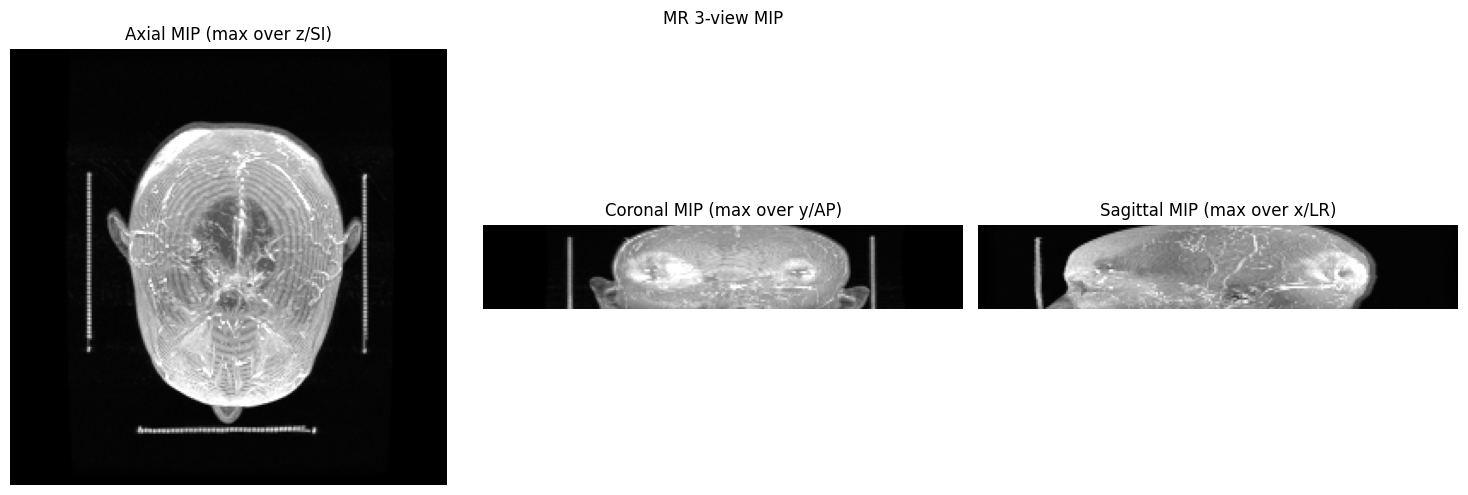

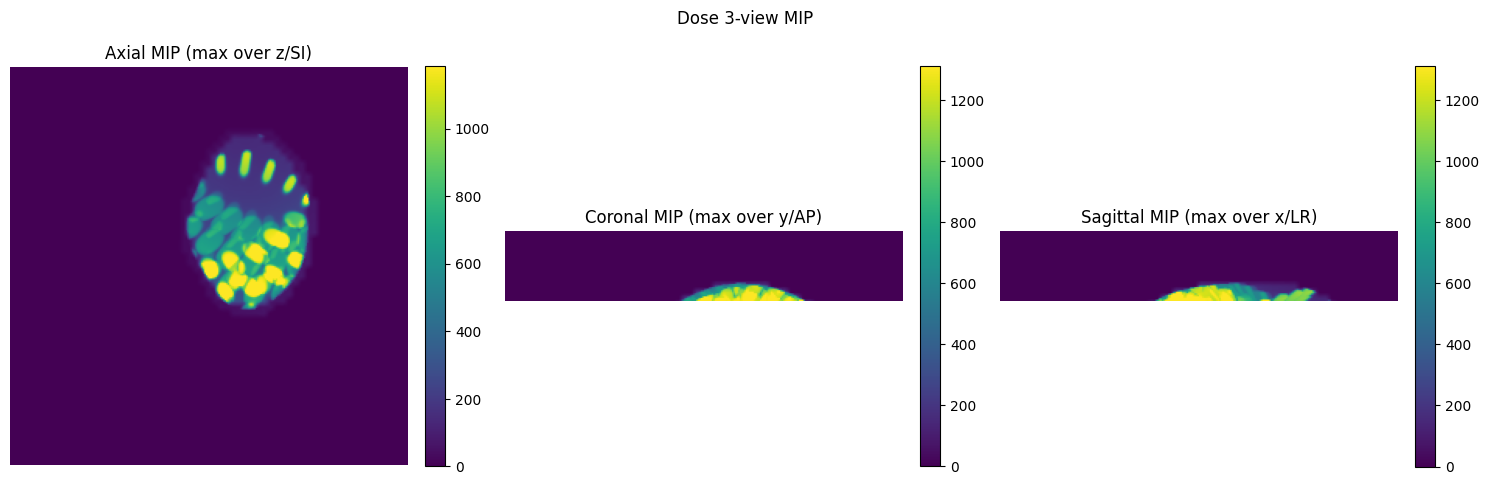

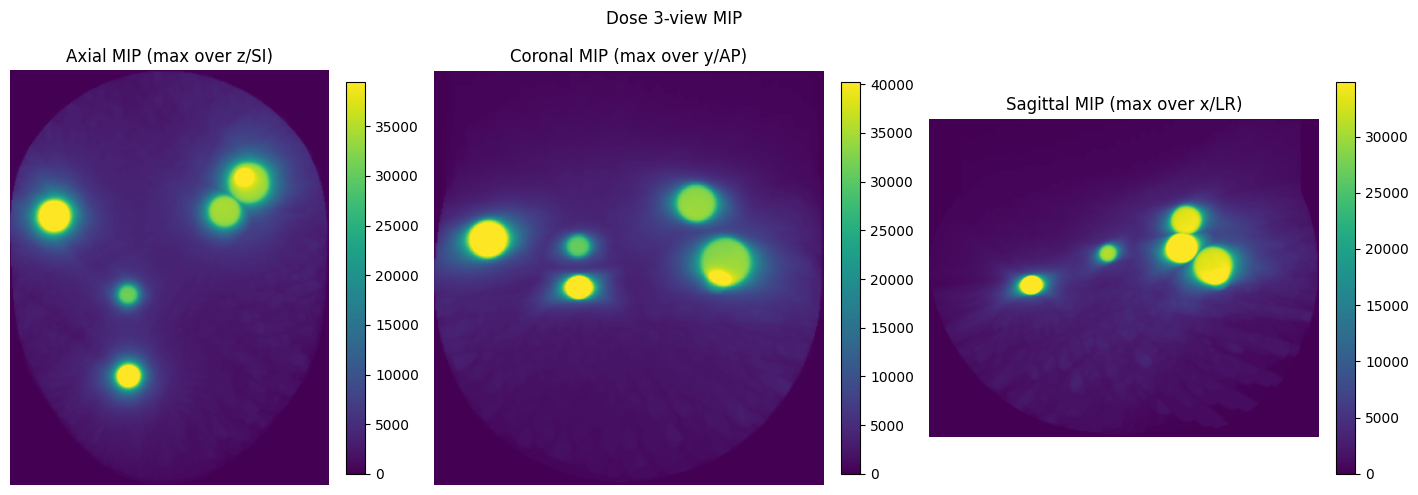

(<Figure size 1500x500 with 6 Axes>,
 array([<Axes: title={'center': 'Axial MIP (max over z/SI)'}>,
        <Axes: title={'center': 'Coronal MIP (max over y/AP)'}>,
        <Axes: title={'center': 'Sagittal MIP (max over x/LR)'}>],
       dtype=object))

In [38]:
plot_3view_mip(mr_np, cmap="gray", suptitle="MR 3-view MIP")
plot_3view_mip(dose_np, assume_nonnegative=True, suptitle="Dose 3-view MIP", add_colorbar=True)


plot_3view_mip(sitk.GetArrayFromImage(rtdose_img).astype(np.float32), assume_nonnegative=True, suptitle="Dose 3-view MIP", add_colorbar=True)